# Adaptive Cognitive UI

AI akan mengklasifikasikan pengguna MSME pedesaan ASEAN ke dalam 4 profil UI berdasarkan perilaku interaksi mereka dengan aplikasi. Notebook ini menghasilkan data sintetis untuk fitur Adaptive Cognitive UI.

Profil UI:
- Guided -> Pengguna lansia / pertama kali digital, butuh panduan penuh
- Simplified -> Pengguna yang paham dasar tapi kesulitan di alur multi-langkah
- Standard -> Pengguna smartphone yang nyaman dengan pola UI standar
- Efficient -> Pengguna mahir teknologi, butuh UI kompak dan cepat

Ringkasan Data:
- users -> 5000 data (dari datas/users.csv)
- ui_behavior_sessions -> 100.000 data (5000 user x 20 sesi)
- ui_profiles -> 5000 data (mapping user ke profil UI)
- Aggregated features -> 5000 data (untuk XGBoost)
- Sequence tensors -> (5000, 20, 14) tensor (untuk LSTM/GRU)

# Data Generation

## Setup

### Environment Setup

In [1]:
!pip install onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 94.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 104.1 MB/s eta 0:00:0000:0100:01


In [2]:
import numpy as np
import pandas as pd
import json
import os
import torch
import warnings
from datetime import datetime, timedelta
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

### Configuration

In [ ]:
"""
Global configuration untuk Adaptive Cognitive UI data generation.
"""

config = {
    'num_users': 5000,
    'sessions_per_user': 20,
    'num_session_features': 14,
    'random_seed': 42,

    'train_split': 0.70,
    'val_split': 0.15,
    'test_split': 0.15,

    'profile_labels': {
        0: 'guided',
        1: 'simplified',
        2: 'standard',
        3: 'efficient'
    },

    'class_names': ['guided', 'simplified', 'standard', 'efficient'],

    'target_distribution': {
        'guided': 0.15,
        'simplified': 0.30,
        'standard': 0.35,
        'efficient': 0.20
    },

    'session_feature_names': [
        'hesitation_time_ms',
        'back_button_per_session',
        'rapid_back_sequences',
        'scroll_speed_px_s',
        'scroll_direction_changes',
        'scroll_overshoot_rate',
        'abandon_rate',
        'tap_precision_score',
        'double_tap_rate',
        'time_between_actions_ms',
        'feature_usage_breadth',
        'session_duration_sec',
        'error_encounter_rate',
        'help_button_usage'
    ],

    'num_classes': 4,
    'batch_size': 64,
    'num_epochs': 100,
    'patience': 15,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,

    'lstm_hidden_size': 64,
    'gru_hidden_size': 64,
    'num_rnn_layers': 2,
    'rnn_dropout': 0.3,
    'bidirectional': True,

    'xgb_n_estimators': 300,
    'xgb_max_depth': 6,
    'xgb_learning_rate': 0.05,
    'xgb_subsample': 0.8,
    'xgb_colsample_bytree': 0.8
}

np.random.seed(config['random_seed'])
torch.manual_seed(config['random_seed'])

f"Configuration loaded: {config['num_users']} users, {config['sessions_per_user']} sessions each, {config['num_session_features']} features per session"

'Configuration loaded: 5000 users, 20 sessions each, 14 features per session'

### Path Setup

In [4]:
# """Base path ke folder AI-Lab/model-dev/"""
# datas_path = '../datas'
# models_path = '../models'

"""Base path untuk Google Drive storage"""
from google.colab import drive
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon'
datas_path = f'{base_path}/datas'
models_path = f'{base_path}/models'

Path(f'{datas_path}').mkdir(parents=True, exist_ok=True)
Path(f'{models_path}').mkdir(parents=True, exist_ok=True)

print(f"datas_path: {datas_path}")
print(f"models_path: {models_path}")

Mounted at /content/drive
datas_path: /content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon/datas
models_path: /content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon/models


## User Data

### Load Existing Users

In [5]:
users = pd.read_csv(f'{datas_path}/users.csv')

"""Tambahkan user_id numerik berdasarkan nama"""
users['user_id'] = users['name'].str.extract(r'(\d+)').astype(int)

print(f"Loaded {len(users)} users from datas/users.csv")
print(f"\nColumns: {list(users.columns)}")
print(f"Age: mean={users['age'].mean():.1f}, range=[{users['age'].min()}, {users['age'].max()}]")
print(f"Occupation codes: {sorted(users['occupation'].unique())}")
print(f"Income: mean={users['monthly_income'].mean():,.0f}")

users.head(10)

Loaded 5000 users from datas/users.csv

Columns: ['name', 'age', 'occupation', 'monthly_income', 'social_status', 'location', 'credit_score', 'user_id']
Age: mean=31.4, range=[18, 45]
Occupation codes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Income: mean=1,560,403


,name,age,occupation,monthly_income,social_status,location,credit_score,user_id
0,name-1,37,10,565569,0,5,0.406204,1
1,name-2,27,1,547271,0,4,0.765431,2
2,name-3,27,4,853682,0,5,0.588724,3
3,name-4,40,1,850212,4,1,0.736884,4
4,name-5,41,8,1001754,1,3,0.706347,5
5,name-6,44,1,954224,2,5,0.583491,6
6,name-7,31,0,755441,0,1,0.410600,7
7,name-8,32,9,1480122,2,3,0.371651,8
8,name-9,31,7,2934045,1,5,0.638244,9
9,name-10,26,5,865649,0,4,0.364402,10


### Digital Literacy Score

Digital Literacy Score Statistics:
  Mean: 0.530
  Std:  0.198
  Min:  0.000
  Max:  1.000


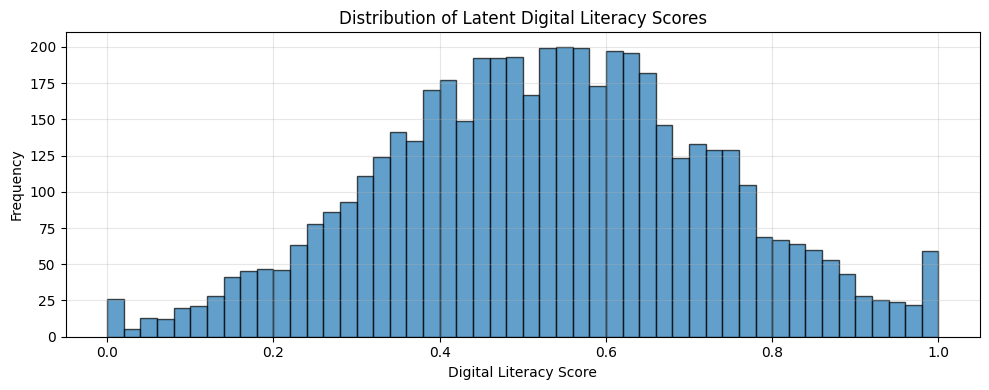

In [6]:
"""
Latent variable: digunakan untuk menentukan ground truth UI profile.
Faktor penentu: age (negatif), occupation modifier, monthly_income (positif), credit_score (positif), dan noise.
"""

occupation_tech_modifier = {
    0: -0.10,
    1: -0.08,
    2: 0.05,
    3: 0.00,
    4: -0.05,
    5: 0.03,
    6: 0.15,
    7: 0.05,
    8: -0.03,
    9: -0.12,
    10: 0.00
}

digital_literacy_scores = []

for _, row in users.iterrows():
    """Age component: younger = higher score (normalized 0-1)"""
    age_component = 1.0 - ((row['age'] - 18) / (75 - 18))
    age_component = np.clip(age_component, 0.0, 1.0)

    """Income component (normalized by reasonable max)"""
    income_component = min(row['monthly_income'] / 2_000_000, 1.0)

    """Credit score sebagai proxy digital maturity"""
    credit_component = float(row['credit_score'])

    """Occupation tech modifier"""
    occ_modifier = occupation_tech_modifier.get(row['occupation'], 0.0)

    """Weighted combination + noise"""
    raw_score = (
        0.20 * age_component +
        0.15 * income_component +
        0.15 * credit_component +
        0.10 * occ_modifier +
        0.40 * np.random.uniform(0.0, 1.0)
    )

    """Noise untuk mencegah mapping deterministik"""
    noise = np.random.normal(0, 0.15)
    final_score = np.clip(raw_score + noise, 0.0, 1.0)

    digital_literacy_scores.append(final_score)

users['digital_literacy_score'] = digital_literacy_scores

print(f"Digital Literacy Score Statistics:")
print(f"  Mean: {users['digital_literacy_score'].mean():.3f}")
print(f"  Std:  {users['digital_literacy_score'].std():.3f}")
print(f"  Min:  {users['digital_literacy_score'].min():.3f}")
print(f"  Max:  {users['digital_literacy_score'].max():.3f}")

plt.figure(figsize=(10, 4))
plt.hist(users['digital_literacy_score'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Digital Literacy Score')
plt.ylabel('Frequency')
plt.title('Distribution of Latent Digital Literacy Scores')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### UI Profile Assignment

In [7]:
"""
Assign UI profile berdasarkan digital_literacy_score.
"""

target_dist = config['target_distribution']

"""Sort user berdasarkan digital_literacy_score"""
users_sorted = users.sort_values('digital_literacy_score').reset_index(drop=True)
n = len(users_sorted)

"""Hitung cumulative cutoff berdasarkan target distribution"""
guided_end = int(n * target_dist['guided'])
simplified_end = guided_end + int(n * target_dist['simplified'])
standard_end = simplified_end + int(n * target_dist['standard'])

"""Assign profile berdasarkan rank"""
profiles = []
for i in range(n):
    if i < guided_end:
        profiles.append('guided')
    elif i < simplified_end:
        profiles.append('simplified')
    elif i < standard_end:
        profiles.append('standard')
    else:
        profiles.append('efficient')

users_sorted['ui_profile'] = profiles

"""Label swap noise -> 8% user di boundary zone mendapat profil tetangga"""
swap_rate = 0.08
n_swaps = int(n * swap_rate)
swap_map = {
    'guided': 'simplified',
    'simplified': ['guided', 'standard'],
    'standard': ['simplified', 'efficient'],
    'efficient': 'standard'
}

rng = np.random.RandomState(config['random_seed'] + 1)
swap_indices = rng.choice(n, size=n_swaps, replace=False)

for idx in swap_indices:
    current = users_sorted.loc[idx, 'ui_profile']
    neighbor = swap_map[current]
    if isinstance(neighbor, list):
        users_sorted.loc[idx, 'ui_profile'] = rng.choice(neighbor)
    else:
        users_sorted.loc[idx, 'ui_profile'] = neighbor

"""Kembalikan ke original order dan merge ke users dataframe"""
users = users.drop(columns=['ui_profile'], errors='ignore')
users = users.merge(
    users_sorted[['user_id', 'ui_profile']],
    on='user_id',
    how='left'
)

profile_to_label = {'guided': 0, 'simplified': 1, 'standard': 2, 'efficient': 3}
users['ui_profile_label'] = users['ui_profile'].map(profile_to_label)

print("UI Profile Distribution:")
dist = users['ui_profile'].value_counts(normalize=True).round(3)
for profile in ['guided', 'simplified', 'standard', 'efficient']:
    count = (users['ui_profile'] == profile).sum()
    target = target_dist[profile]
    pct = dist.get(profile, 0)
    print(f"  {profile:12s}: {count:5d} ({pct:.1%})  [target: {target:.0%}]")

UI Profile Distribution:
  guided      :   765 (15.3%)  [target: 15%]
  simplified  :  1477 (29.5%)  [target: 30%]
  standard    :  1765 (35.3%)  [target: 35%]
  efficient   :   993 (19.9%)  [target: 20%]


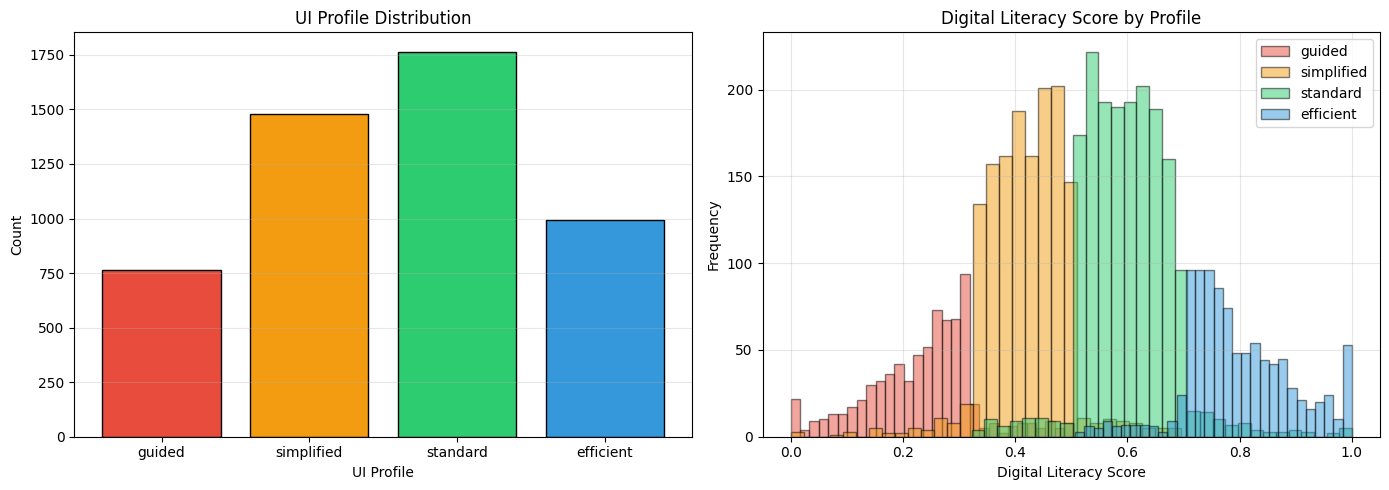

In [8]:
"""
Visualisasi distribusi profil dan hubungan dengan digital literacy score.
"""

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

profile_order = ['guided', 'simplified', 'standard', 'efficient']
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

profile_counts = users['ui_profile'].value_counts().reindex(profile_order)
axes[0].bar(profile_order, profile_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('UI Profile')
axes[0].set_ylabel('Count')
axes[0].set_title('UI Profile Distribution')
axes[0].grid(True, alpha=0.3, axis='y')

for profile, color in zip(profile_order, colors):
    subset = users[users['ui_profile'] == profile]['digital_literacy_score']
    axes[1].hist(subset, bins=30, alpha=0.5, label=profile, color=color, edgecolor='black')

axes[1].set_xlabel('Digital Literacy Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Digital Literacy Score by Profile')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Behavioral Data Generation

### Profile Parameter Definitions

In [9]:
"""
Mendefinisikan range parameter perilaku untuk setiap UI profile.
Range dibuat dengan overlap ~40-60% antar profil bertetangga agar klasifikasi realistis.
"""

profile_params = {
    'guided': {
        'hesitation_time_ms':       (2000, 10000),
        'back_button_per_session':  (2, 12),
        'rapid_back_sequences':     (0, 5),
        'scroll_speed_px_s':        (80, 800),
        'scroll_direction_changes': (2, 10),
        'scroll_overshoot_rate':    (0.10, 0.55),
        'abandon_rate':             (0.15, 0.70),
        'tap_precision_score':      (0.35, 0.78),
        'double_tap_rate':          (0.06, 0.35),
        'time_between_actions_ms':  (2500, 9000),
        'feature_usage_breadth':    (1, 6),
        'session_duration_sec':     (60, 400),
        'error_encounter_rate':     (0.08, 0.45),
        'help_button_usage':        (1, 7)
    },
    'simplified': {
        'hesitation_time_ms':       (1500, 8000),
        'back_button_per_session':  (1, 9),
        'rapid_back_sequences':     (0, 4),
        'scroll_speed_px_s':        (150, 1200),
        'scroll_direction_changes': (1, 8),
        'scroll_overshoot_rate':    (0.05, 0.40),
        'abandon_rate':             (0.08, 0.55),
        'tap_precision_score':      (0.45, 0.88),
        'double_tap_rate':          (0.03, 0.25),
        'time_between_actions_ms':  (1500, 7000),
        'feature_usage_breadth':    (2, 8),
        'session_duration_sec':     (100, 600),
        'error_encounter_rate':     (0.04, 0.30),
        'help_button_usage':        (0, 5)
    },
    'standard': {
        'hesitation_time_ms':       (800, 5000),
        'back_button_per_session':  (0, 6),
        'rapid_back_sequences':     (0, 2),
        'scroll_speed_px_s':        (300, 1800),
        'scroll_direction_changes': (0, 5),
        'scroll_overshoot_rate':    (0.01, 0.25),
        'abandon_rate':             (0.02, 0.35),
        'tap_precision_score':      (0.60, 0.95),
        'double_tap_rate':          (0.00, 0.12),
        'time_between_actions_ms':  (500, 4000),
        'feature_usage_breadth':    (3, 10),
        'session_duration_sec':     (150, 800),
        'error_encounter_rate':     (0.01, 0.18),
        'help_button_usage':        (0, 3)
    },
    'efficient': {
        'hesitation_time_ms':       (200, 3000),
        'back_button_per_session':  (0, 4),
        'rapid_back_sequences':     (0, 1),
        'scroll_speed_px_s':        (500, 2800),
        'scroll_direction_changes': (0, 3),
        'scroll_overshoot_rate':    (0.00, 0.15),
        'abandon_rate':             (0.00, 0.18),
        'tap_precision_score':      (0.72, 1.00),
        'double_tap_rate':          (0.00, 0.06),
        'time_between_actions_ms':  (200, 2000),
        'feature_usage_breadth':    (5, 12),
        'session_duration_sec':     (80, 600),
        'error_encounter_rate':     (0.00, 0.10),
        'help_button_usage':        (0, 2)
    }
}

"""Occupation based modifiers menggunakan kode integer dari users.csv"""
occupation_behavior_modifier = {
    0:  {'session_duration_sec': 0.7, 'feature_usage_breadth': 0.8},
    1:  {'session_duration_sec': 0.6, 'feature_usage_breadth': 0.7},
    2:  {'session_duration_sec': 1.1, 'feature_usage_breadth': 1.1},
    3:  {'session_duration_sec': 0.9, 'feature_usage_breadth': 0.9},
    4:  {'session_duration_sec': 0.8, 'feature_usage_breadth': 0.8},
    5:  {'session_duration_sec': 1.0, 'feature_usage_breadth': 1.0},
    6:  {'session_duration_sec': 0.8, 'feature_usage_breadth': 1.2},
    7:  {'session_duration_sec': 1.0, 'feature_usage_breadth': 1.0},
    8:  {'session_duration_sec': 0.7, 'feature_usage_breadth': 0.85},
    9:  {'session_duration_sec': 0.6, 'feature_usage_breadth': 0.75},
    10: {'session_duration_sec': 0.9, 'feature_usage_breadth': 0.9}
}

f"Defined behavioral parameters for {len(profile_params)} profiles with {len(config['session_feature_names'])} features each"

'Defined behavioral parameters for 4 profiles with 14 features each'

### Per Session Behavioral Data

In [10]:
"""
Generate data perilaku per sesi untuk setiap user.
Total output: 5000 users x 20 sessions = 100.000 records.
"""

neighbor_profiles = {
    'guided': ['simplified'],
    'simplified': ['guided', 'standard'],
    'standard': ['simplified', 'efficient'],
    'efficient': ['standard']
}
inconsistent_rate = 0.22

all_sessions = []

for _, user in users.iterrows():
    profile = user['ui_profile']
    occupation = user['occupation']
    occ_mod = occupation_behavior_modifier.get(occupation, {})

    """Per-user, per-feature random multiplier: Beta(1.5, 1.5) independen tiap fitur"""
    user_multipliers = {
        feat: np.random.beta(1.5, 1.5) for feat in config['session_feature_names']
    }

    """Per-user feature bias: noise tambahan yang konsisten per user tapi independen per fitur"""
    user_feature_bias = {}
    for feat in config['session_feature_names']:
        f_min, f_max = profile_params[profile][feat]
        user_feature_bias[feat] = np.random.normal(0, 0.15 * (f_max - f_min))

    for session_idx in range(config['sessions_per_user']):
        session_data = {
            'user_id': user['user_id'],
            'session_idx': session_idx
        }

        """22% chance: session menggunakan parameter dari profil tetangga"""
        if np.random.random() < inconsistent_rate:
            session_profile = np.random.choice(neighbor_profiles[profile])
        else:
            session_profile = profile

        params = profile_params[session_profile]

        for feature_name in config['session_feature_names']:
            f_min, f_max = params[feature_name]

            """Base value menggunakan per-user per-feature multiplier"""
            base_value = f_min + user_multipliers[feature_name] * (f_max - f_min)

            """Tambahkan user-level feature bias (personal habit noise)"""
            base_value += user_feature_bias[feature_name]

            noise_scale = (f_max - f_min) * 0.50
            session_noise = np.random.normal(0, noise_scale)
            value = base_value + session_noise

            if feature_name in occ_mod:
                value *= occ_mod[feature_name]

            if feature_name in ['scroll_overshoot_rate', 'abandon_rate', 'tap_precision_score',
                                'double_tap_rate', 'error_encounter_rate']:
                value = np.clip(value, 0.0, 1.0)
            elif feature_name in ['back_button_per_session', 'rapid_back_sequences',
                                  'scroll_direction_changes', 'feature_usage_breadth',
                                  'help_button_usage']:
                value = max(0, round(value))
            else:
                value = max(0, value)

            session_data[feature_name] = value

        all_sessions.append(session_data)

sessions_df = pd.DataFrame(all_sessions)

print(f"Generated {len(sessions_df)} session records")
print(f"Users: {sessions_df['user_id'].nunique()}")
print(f"Sessions per user: {sessions_df.groupby('user_id').size().mean():.0f}")
print(f"\nFeature statistics (mean across all sessions):")
for feat in config['session_feature_names']:
    print(f"  {feat:30s}: {sessions_df[feat].mean():10.2f}  (std={sessions_df[feat].std():.2f})")

Generated 100000 session records
Users: 5000
Sessions per user: 20

Feature statistics (mean across all sessions):
  hesitation_time_ms            :    3841.23  (std=3267.20)
  back_button_per_session       :       4.35  (std=3.97)
  rapid_back_sequences          :       1.60  (std=1.77)
  scroll_speed_px_s             :    1010.03  (std=884.79)
  scroll_direction_changes      :       3.74  (std=3.42)
  scroll_overshoot_rate         :       0.19  (std=0.18)
  abandon_rate                  :       0.25  (std=0.23)
  tap_precision_score           :       0.72  (std=0.22)
  double_tap_rate               :       0.11  (std=0.11)
  time_between_actions_ms       :    3280.00  (std=2896.34)
  feature_usage_breadth         :       5.54  (std=3.70)
  session_duration_sec          :     324.66  (std=259.30)
  error_encounter_rate          :       0.14  (std=0.14)
  help_button_usage             :       2.29  (std=2.31)


In [11]:
"""
Verifikasi distribusi fitur berbeda antar profil.
"""

sessions_with_profile = sessions_df.merge(
    users[['user_id', 'ui_profile']],
    on='user_id'
)

print("Per-profile mean values for key features:")
print("=" * 80)

key_features = ['hesitation_time_ms', 'back_button_per_session', 'tap_precision_score',
                'scroll_speed_px_s', 'abandon_rate', 'session_duration_sec']

profile_means = sessions_with_profile.groupby('ui_profile')[key_features].mean()
profile_means = profile_means.reindex(['guided', 'simplified', 'standard', 'efficient'])

print(profile_means.round(2).to_string())

Per-profile mean values for key features:
            hesitation_time_ms  back_button_per_session  tap_precision_score  scroll_speed_px_s  abandon_rate  session_duration_sec
ui_profile                                                                                                                         
guided                 5976.30                     6.87                 0.58             523.47          0.40                220.29
simplified             4870.29                     5.37                 0.66             734.13          0.33                302.42
standard               3072.39                     3.42                 0.76            1122.55          0.20                390.96
efficient              2032.32                     2.53                 0.82            1595.25          0.13                320.32


## Export Data

In [12]:
"""Session behavioral data"""
sessions_df.to_csv(f'{datas_path}/ui-behavior-sessions.csv', index=False)
print(f"Saved: ui-behavior-sessions.csv ({len(sessions_df)} rows)")

"""User to profile mapping"""
profiles_export = users[['user_id', 'name', 'ui_profile', 'ui_profile_label']].copy()
profiles_export.to_csv(f'{datas_path}/ui-profiles.csv', index=False)
print(f"Saved: ui-profiles.csv ({len(profiles_export)} rows)")

Saved: ui-behavior-sessions.csv (100000 rows)
Saved: ui-profiles.csv (5000 rows)


## Summary

In [13]:
"""Summary data generation"""

print(f"\nUsers loaded from: {datas_path}/users.csv ({len(users)})")
print(f"Total sessions generated: {len(sessions_df)}")
print(f"Session features: {config['num_session_features']}")
print(f"\nProfile distribution:")
for profile in ['guided', 'simplified', 'standard', 'efficient']:
    count = int((users['ui_profile'] == profile).sum())
    print(f"  {profile:12s}: {count:5d} ({count/len(users):.1%})")
print(f"\nRaw data exported to: {os.path.abspath(datas_path)}/")
print(f"  - ui-behavior-sessions.csv")
print(f"  - ui-profiles.csv")


Users loaded from: /content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon/datas/users.csv (5000)
Total sessions generated: 100000
Session features: 14

Profile distribution:
  guided      :   765 (15.3%)
  simplified  :  1477 (29.5%)
  standard    :  1765 (35.3%)
  efficient   :   993 (19.9%)

Raw data exported to: /content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon/datas/
  - ui-behavior-sessions.csv
  - ui-profiles.csv


# Modeling

## Setup

In [14]:
"""Import tambahan untuk modeling"""

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.manifold import TSNE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Feature Engineering

### Aggregated Features for XGBoost

In [15]:
"""
Aggregate per user: hitung mean, median, std, min, max untuk setiap session feature.
14 fitur x 5 statistik = 70 fitur + 1 (sessions_count) = 71 fitur per user.
"""

feature_cols = config['session_feature_names']

agg_funcs = ['mean', 'median', 'std', 'min', 'max']
agg_dict = {feat: agg_funcs for feat in feature_cols}

aggregated = sessions_df.groupby('user_id').agg(agg_dict)
aggregated.columns = [f'{feat}_{stat}' for feat, stat in aggregated.columns]
aggregated = aggregated.reset_index()

"""Tambahkan session count"""
session_counts = sessions_df.groupby('user_id').size().reset_index(name='sessions_count')
aggregated = aggregated.merge(session_counts, on='user_id')

"""Merge dengan label"""
aggregated = aggregated.merge(
    users[['user_id', 'ui_profile', 'ui_profile_label']],
    on='user_id'
)

"""Fill NaN std values"""
aggregated = aggregated.fillna(0)

feature_columns = [c for c in aggregated.columns if c not in ['user_id', 'ui_profile', 'ui_profile_label']]

print(f"Aggregated dataset shape: {aggregated.shape}")
print(f"Number of features: {len(feature_columns)}")
print(f"\nSample features: {feature_columns[:10]}")

aggregated.head()

Aggregated dataset shape: (5000, 74)
Number of features: 71

Sample features: ['hesitation_time_ms_mean', 'hesitation_time_ms_median', 'hesitation_time_ms_std', 'hesitation_time_ms_min', 'hesitation_time_ms_max', 'back_button_per_session_mean', 'back_button_per_session_median', 'back_button_per_session_std', 'back_button_per_session_min', 'back_button_per_session_max']


,user_id,hesitation_time_ms_mean,hesitation_time_ms_median,hesitation_time_ms_std,hesitation_time_ms_min,hesitation_time_ms_max,back_button_per_session_mean,back_button_per_session_median,back_button_per_session_std,back_button_per_session_min,...,error_encounter_rate_min,error_encounter_rate_max,help_button_usage_mean,help_button_usage_median,help_button_usage_std,help_button_usage_min,help_button_usage_max,sessions_count,ui_profile,ui_profile_label
0,1,6462.746339,7044.805306,3907.305232,0.000000,11592.758511,6.35,6.0,5.193873,0,...,0.015518,0.559907,3.65,4.0,1.843195,0,7,20,guided,0
1,2,5366.731770,4493.667537,3749.636605,112.101481,14086.786178,7.05,8.0,3.953346,0,...,0.000000,0.414130,1.55,0.0,2.416500,0,7,20,simplified,1
2,3,7667.960415,7701.261327,5160.659650,0.000000,18321.167332,6.75,6.0,4.598341,1,...,0.046360,0.468401,4.65,4.0,2.719810,0,10,20,simplified,1
3,4,2062.429961,1209.949166,2298.128331,0.000000,8999.422714,1.45,0.5,2.305029,0,...,0.000000,0.202879,1.70,2.0,1.218282,0,4,20,efficient,3
4,5,6479.092363,7205.451264,3419.810589,0.000000,12031.360544,3.30,2.5,3.961658,0,...,0.000000,0.348996,4.15,4.5,2.777257,0,9,20,guided,0


### Sequence Features for LSTM/GRU

In [16]:
"""
Shape: (num_users, sessions_per_user, num_features) = (5000, 20, 14)
Setiap timestep merepresentasikan satu sesi interaksi user.
"""

num_users = config['num_users']
seq_len = config['sessions_per_user']
num_features = config['num_session_features']

sequences = np.zeros((num_users, seq_len, num_features))
labels = np.zeros(num_users, dtype=np.int64)
user_ids_ordered = []

for idx, (user_id, group) in enumerate(sessions_df.groupby('user_id')):
    group_sorted = group.sort_values('session_idx')
    feature_values = group_sorted[feature_cols].values

    """Pad atau truncate ke fixed length"""
    actual_len = min(len(feature_values), seq_len)
    sequences[idx, :actual_len, :] = feature_values[:actual_len]

    user_label = users[users['user_id'] == user_id]['ui_profile_label'].values[0]
    labels[idx] = user_label
    user_ids_ordered.append(user_id)

print(f"Sequence tensor shape: {sequences.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Label distribution: {dict(zip(*np.unique(labels, return_counts=True)))}")

Sequence tensor shape: (5000, 20, 14)
Labels shape: (5000,)
Label distribution: {np.int64(0): np.int64(765), np.int64(1): np.int64(1477), np.int64(2): np.int64(1765), np.int64(3): np.int64(993)}


## Train / Validation / Test Split

In [17]:
"""
Stratified split 70/15/15 dan User-level split.
"""

from sklearn.model_selection import train_test_split

indices = np.arange(len(labels))

"""Split: 70% train, 30% temp"""
train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, random_state=config['random_seed'],
    stratify=labels
)

"""Split temp: 50/50 -> 15% val, 15% test"""
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=config['random_seed'],
    stratify=labels[temp_idx]
)

"""Sequence splits"""
X_train_seq_raw = sequences[train_idx]
X_val_seq_raw = sequences[val_idx]
X_test_seq_raw = sequences[test_idx]
y_train_arr = labels[train_idx]
y_val_arr = labels[val_idx]
y_test_arr = labels[test_idx]

"""Tabular splits (aggregated data)"""
train_users = [user_ids_ordered[i] for i in train_idx]
val_users = [user_ids_ordered[i] for i in val_idx]
test_users = [user_ids_ordered[i] for i in test_idx]

tab_train = aggregated[aggregated['user_id'].isin(train_users)].copy()
tab_val = aggregated[aggregated['user_id'].isin(val_users)].copy()
tab_test = aggregated[aggregated['user_id'].isin(test_users)].copy()

print(f"Split sizes:")
print(f"  Train: {len(train_idx)} ({len(train_idx)/len(indices)*100:.1f}%)")
print(f"  Val:   {len(val_idx)} ({len(val_idx)/len(indices)*100:.1f}%)")
print(f"  Test:  {len(test_idx)} ({len(test_idx)/len(indices)*100:.1f}%)")
print(f"\nLabel distribution (train): {dict(zip(*np.unique(y_train_arr, return_counts=True)))}")
print(f"Label distribution (val):   {dict(zip(*np.unique(y_val_arr, return_counts=True)))}")
print(f"Label distribution (test):  {dict(zip(*np.unique(y_test_arr, return_counts=True)))}")

Split sizes:
  Train: 3500 (70.0%)
  Val:   750 (15.0%)
  Test:  750 (15.0%)

Label distribution (train): {np.int64(0): np.int64(535), np.int64(1): np.int64(1034), np.int64(2): np.int64(1236), np.int64(3): np.int64(695)}
Label distribution (val):   {np.int64(0): np.int64(115), np.int64(1): np.int64(221), np.int64(2): np.int64(265), np.int64(3): np.int64(149)}
Label distribution (test):  {np.int64(0): np.int64(115), np.int64(1): np.int64(222), np.int64(2): np.int64(264), np.int64(3): np.int64(149)}


## Feature Scaling

In [18]:
"""
Sequence data: flatten -> scale -> reshape.
Tabular data: scale feature columns secara langsung.
"""

from sklearn.preprocessing import StandardScaler

"""Scale sequence data"""
seq_scaler = StandardScaler()
n_train, sl, nf = X_train_seq_raw.shape

seq_scaler.fit(X_train_seq_raw.reshape(-1, nf))

X_train_seq_scaled = seq_scaler.transform(X_train_seq_raw.reshape(-1, nf)).reshape(n_train, sl, nf)
X_val_seq_scaled = seq_scaler.transform(X_val_seq_raw.reshape(-1, nf)).reshape(len(val_idx), sl, nf)
X_test_seq_scaled = seq_scaler.transform(X_test_seq_raw.reshape(-1, nf)).reshape(len(test_idx), sl, nf)

"""Convert to tensors"""
X_train_seq = torch.FloatTensor(X_train_seq_scaled)
X_val_seq = torch.FloatTensor(X_val_seq_scaled)
X_test_seq = torch.FloatTensor(X_test_seq_scaled)
y_train = torch.LongTensor(y_train_arr)
y_val = torch.LongTensor(y_val_arr)
y_test = torch.LongTensor(y_test_arr)

"""Scale tabular data"""
tab_feature_cols = [c for c in tab_train.columns if c not in ['user_id', 'ui_profile', 'ui_profile_label']]
tab_scaler = StandardScaler()

X_train_tab = tab_scaler.fit_transform(tab_train[tab_feature_cols].values)
X_val_tab = tab_scaler.transform(tab_val[tab_feature_cols].values)
X_test_tab = tab_scaler.transform(tab_test[tab_feature_cols].values)
y_train_tab = tab_train['ui_profile_label'].values
y_val_tab = tab_val['ui_profile_label'].values
y_test_tab = tab_test['ui_profile_label'].values

print(f"Sequence tensors: train={X_train_seq.shape}, val={X_val_seq.shape}, test={X_test_seq.shape}")
print(f"Tabular arrays:   train={X_train_tab.shape}, val={X_val_tab.shape}, test={X_test_tab.shape}")
print(f"Features: {len(tab_feature_cols)} tabular, {nf} sequential")

Sequence tensors: train=torch.Size([3500, 20, 14]), val=torch.Size([750, 20, 14]), test=torch.Size([750, 20, 14])
Tabular arrays:   train=(3500, 71), val=(750, 71), test=(750, 71)
Features: 71 tabular, 14 sequential


## Data Quality Validation

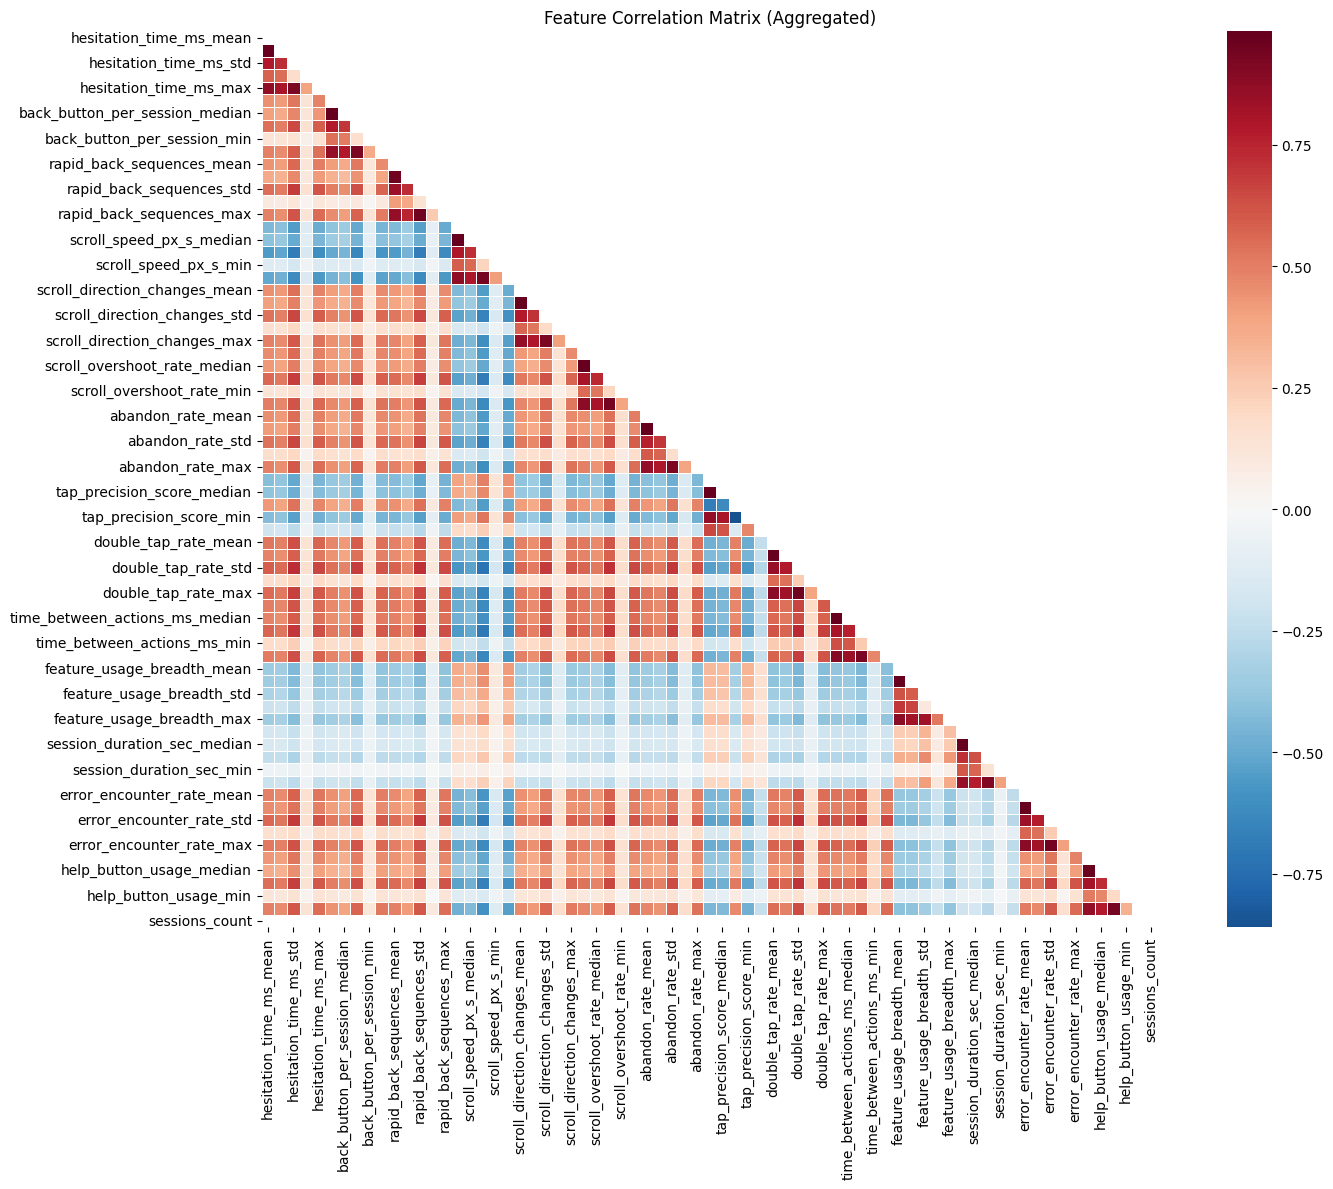

Highly correlated pairs (|r| > 0.9):
  hesitation_time_ms_mean <-> hesitation_time_ms_median: 0.979
  hesitation_time_ms_std <-> hesitation_time_ms_max: 0.925
  back_button_per_session_mean <-> back_button_per_session_median: 0.973
  back_button_per_session_std <-> back_button_per_session_max: 0.926
  rapid_back_sequences_mean <-> rapid_back_sequences_median: 0.953
  rapid_back_sequences_std <-> rapid_back_sequences_max: 0.948
  scroll_speed_px_s_mean <-> scroll_speed_px_s_median: 0.976
  scroll_speed_px_s_std <-> scroll_speed_px_s_max: 0.935
  scroll_direction_changes_mean <-> scroll_direction_changes_median: 0.974
  scroll_direction_changes_std <-> scroll_direction_changes_max: 0.923
  scroll_overshoot_rate_mean <-> scroll_overshoot_rate_median: 0.977
  scroll_overshoot_rate_std <-> scroll_overshoot_rate_max: 0.937
  abandon_rate_mean <-> abandon_rate_median: 0.980
  abandon_rate_std <-> abandon_rate_max: 0.924
  tap_precision_score_mean <-> tap_precision_score_median: 0.980
  double

In [19]:
"""
Correlation heatmap antar fitur.
"""

corr_matrix = aggregated[feature_columns].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    annot=False,
    fmt='.2f',
    square=True,
    linewidths=0.5
)
plt.title('Feature Correlation Matrix (Aggregated)')
plt.tight_layout()
plt.show()

"""Identifikasi highly correlated pairs"""
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    print(f"Highly correlated pairs (|r| > 0.9):")
    for f1, f2, r in high_corr_pairs:
        print(f"  {f1} <-> {f2}: {r:.3f}")
else:
    print("No highly correlated feature pairs found (|r| > 0.9)")

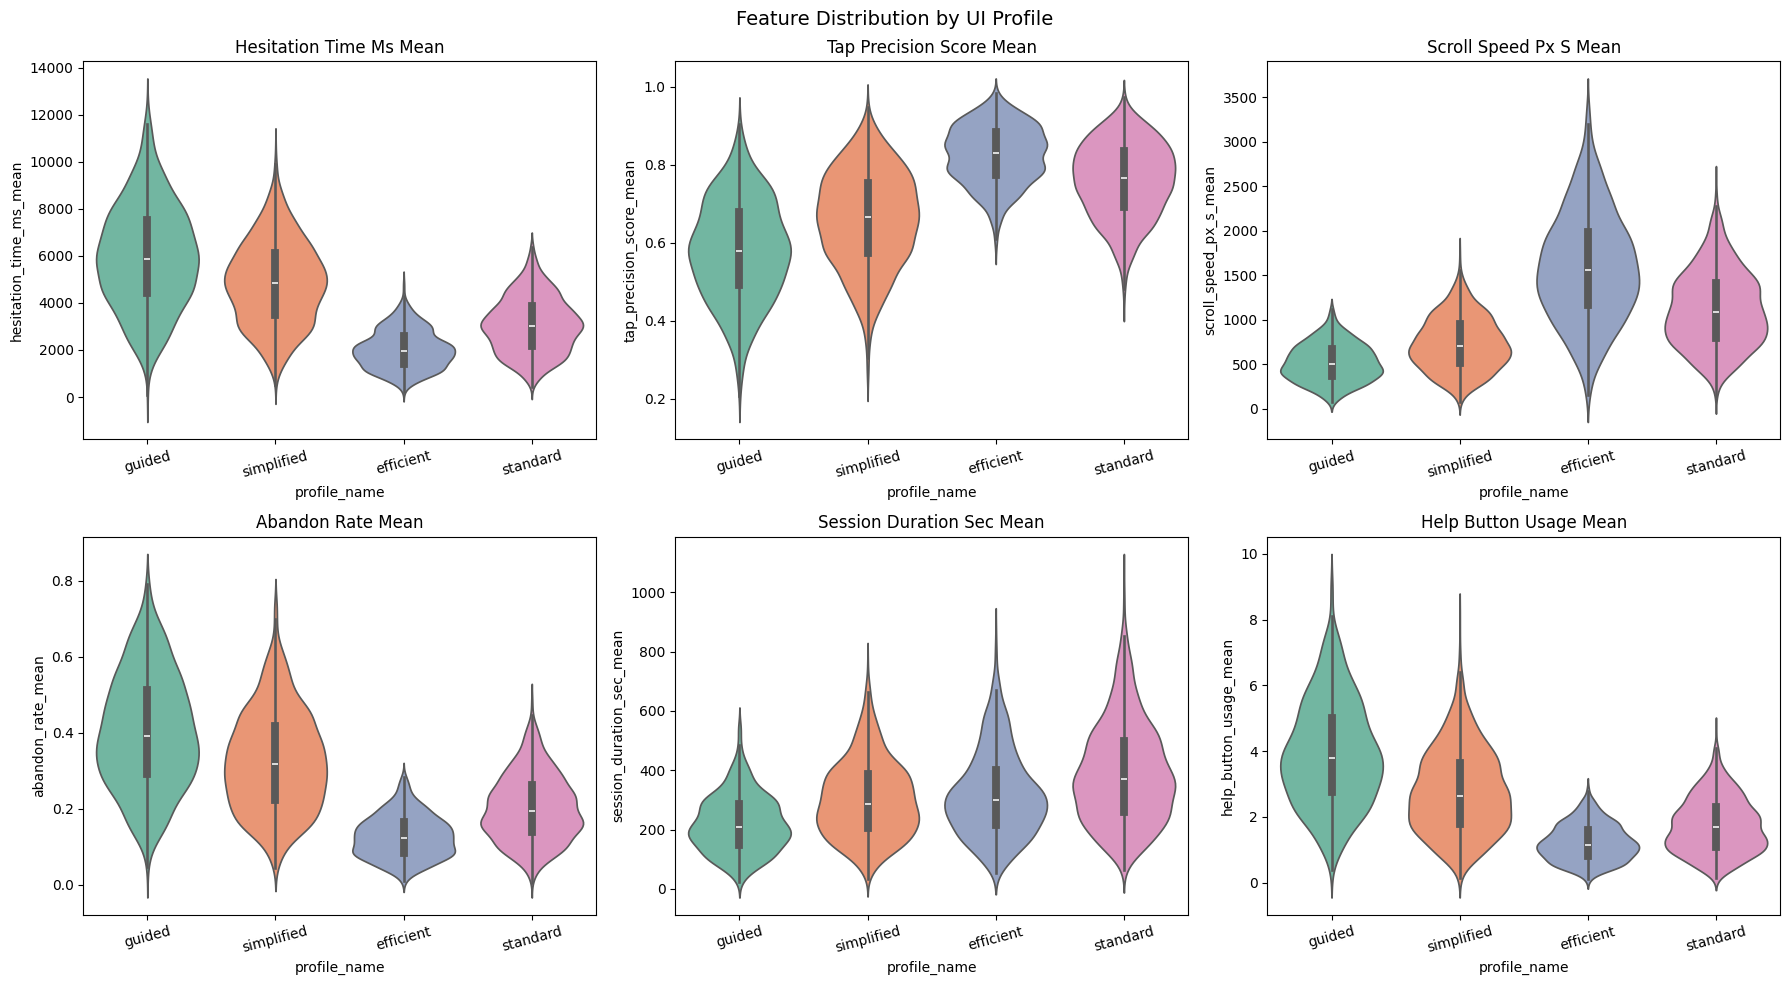

In [20]:
"""
Violin plots: distribusi fitur per UI profile.
"""

plot_features = ['hesitation_time_ms_mean', 'tap_precision_score_mean',
                 'scroll_speed_px_s_mean', 'abandon_rate_mean',
                 'session_duration_sec_mean', 'help_button_usage_mean']

available_features = [f for f in plot_features if f in aggregated.columns]

if available_features:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    profile_names = config['class_names']
    aggregated['profile_name'] = aggregated['ui_profile_label'].map(
        {i: name for i, name in enumerate(profile_names)}
    )

    for idx, feat in enumerate(available_features):
        sns.violinplot(
            data=aggregated,
            x='profile_name',
            y=feat,
            ax=axes[idx],
            palette='Set2',
            inner='box'
        )
        axes[idx].set_title(feat.replace('_', ' ').title())
        axes[idx].tick_params(axis='x', rotation=15)

    for idx in range(len(available_features), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Feature Distribution by UI Profile', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No matching features found for violin plots")

## Data Preprocessing

In [21]:
"""
DataLoader untuk LSTM/GRU training.
Class weights untuk menangani class imbalance.
"""

train_dataset = TensorDataset(X_train_seq, y_train)
val_dataset = TensorDataset(X_val_seq, y_val)
test_dataset = TensorDataset(X_test_seq, y_test)

train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False)

"""Compute class weights (inverse frequency)"""
unique_classes, class_counts = torch.unique(y_train, return_counts=True)
total_samples = y_train.shape[0]
class_weights = total_samples / (len(unique_classes) * class_counts.float())
class_weights = class_weights.to(device)

print(f"DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")
print(f"\nClass distribution (train):")
for cls, count, weight in zip(unique_classes, class_counts, class_weights):
    print(f"  Class {cls.item()} ({config['class_names'][cls.item()]:12s}): {count.item():5d} samples, weight={weight.item():.3f}")

DataLoaders created:
  Train batches: 55
  Val batches: 12
  Test batches: 12

Class distribution (train):
  Class 0 (guided      ):   535 samples, weight=1.636
  Class 1 (simplified  ):  1034 samples, weight=0.846
  Class 2 (standard    ):  1236 samples, weight=0.708
  Class 3 (efficient   ):   695 samples, weight=1.259


## Model Architecture

### LSTM Classifier

In [22]:
class LSTMClassifier(nn.Module):
    """
    Bidirectional LSTM untuk klasifikasi UI profile dari sequence behavioral data.
    Input: (batch, seq_len, input_size) -> Output: (batch, num_classes)
    Menggunakan last hidden state dari kedua arah, diproses melalui FC layers.
    """

    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout, bidirectional):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        fc_input_size = hidden_size * self.num_directions
        self.fc = nn.Sequential(
            nn.Linear(fc_input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout + 0.1),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        """Forward pass: LSTM -> last hidden -> FC layers"""
        lstm_out, (hidden, _) = self.lstm(x)

        if self.bidirectional:
            hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden_cat = hidden[-1]

        out = self.fc(hidden_cat)
        return out

    def get_embeddings(self, x):
        """Ekstrak penultimate layer embeddings untuk visualisasi t-SNE"""
        lstm_out, (hidden, _) = self.lstm(x)

        if self.bidirectional:
            hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden_cat = hidden[-1]

        """Return output setelah penultimate FC layer"""
        for layer in list(self.fc.children())[:-1]:
            hidden_cat = layer(hidden_cat)
        return hidden_cat


f"LSTMClassifier defined"

'LSTMClassifier defined'

### GRU Classifier

In [23]:
class GRUClassifier(nn.Module):
    """
    Bidirectional GRU untuk klasifikasi UI profile.
    Arsitektur identik dengan LSTM tapi menggunakan GRU cell (lebih sedikit parameter).
    """

    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout, bidirectional):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        fc_input_size = hidden_size * self.num_directions
        self.fc = nn.Sequential(
            nn.Linear(fc_input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout + 0.1),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        """Forward pass: GRU -> last hidden -> FC layers"""
        gru_out, hidden = self.gru(x)

        if self.bidirectional:
            hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden_cat = hidden[-1]

        out = self.fc(hidden_cat)
        return out

    def get_embeddings(self, x):
        """Ekstrak penultimate layer embeddings untuk visualisasi t-SNE"""
        gru_out, hidden = self.gru(x)

        if self.bidirectional:
            hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden_cat = hidden[-1]

        for layer in list(self.fc.children())[:-1]:
            hidden_cat = layer(hidden_cat)
        return hidden_cat


f"GRUClassifier defined"

'GRUClassifier defined'

### Model Initialization

In [24]:
input_size = X_train_seq.shape[2]

lstm_model = LSTMClassifier(
    input_size=input_size,
    hidden_size=config['lstm_hidden_size'],
    num_layers=config['num_rnn_layers'],
    num_classes=config['num_classes'],
    dropout=config['rnn_dropout'],
    bidirectional=config['bidirectional']
).to(device)

gru_model = GRUClassifier(
    input_size=input_size,
    hidden_size=config['gru_hidden_size'],
    num_layers=config['num_rnn_layers'],
    num_classes=config['num_classes'],
    dropout=config['rnn_dropout'],
    bidirectional=config['bidirectional']
).to(device)

lstm_params = sum(p.numel() for p in lstm_model.parameters())
gru_params = sum(p.numel() for p in gru_model.parameters())
lstm_size_kb = sum(p.numel() * p.element_size() for p in lstm_model.parameters()) / 1024
gru_size_kb = sum(p.numel() * p.element_size() for p in gru_model.parameters()) / 1024

print(f"LSTM Classifier:")
print(f"  Parameters: {lstm_params:,}")
print(f"  Size: {lstm_size_kb:.2f} KB")
print(f"\nGRU Classifier:")
print(f"  Parameters: {gru_params:,}")
print(f"  Size: {gru_size_kb:.2f} KB")
print(f"\nParameter reduction (GRU vs LSTM): {(1 - gru_params/lstm_params)*100:.1f}%")

LSTM Classifier:
  Parameters: 165,700
  Size: 647.27 KB

GRU Classifier:
  Parameters: 130,628
  Size: 510.27 KB

Parameter reduction (GRU vs LSTM): 21.2%


## Training Functions

In [25]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Single training epoch dengan gradient clipping"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, accuracy, f1


@torch.no_grad()
def evaluate_model(model, loader, criterion):
    """Evaluasi model pada dataset tertentu"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        total_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, accuracy, f1


def train_rnn_model(model, model_name, train_loader, val_loader, config, class_weights):
    """
    Training loop lengkap dengan early stopping dan LR scheduler.
    Return: trained model, training history
    """
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=8
    )

    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': [], 'lr': []
    }

    best_val_f1 = 0
    patience_counter = 0
    best_state = None

    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")

    for epoch in range(config['num_epochs']):
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, val_f1 = evaluate_model(model, val_loader, criterion)

        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['lr'].append(current_lr)

        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{config['num_epochs']} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} F1: {train_f1:.3f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f} F1: {val_f1:.3f} | "
                  f"LR: {current_lr:.6f}")

        if patience_counter >= config['patience']:
            print(f"\nEarly stopping at epoch {epoch+1} (best val F1: {best_val_f1:.4f})")
            break

    """Restore best model"""
    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    print(f"\n{model_name} training complete. Best Val F1: {best_val_f1:.4f}")
    return model, history


f"Training functions defined"

'Training functions defined'

## Training: LSTM

In [26]:
lstm_model, lstm_history = train_rnn_model(
    lstm_model,
    'LSTM Classifier',
    train_loader,
    val_loader,
    config,
    class_weights
)


Training LSTM Classifier
Epoch   1/100 | Train Loss: 0.7288 Acc: 0.688 F1: 0.692 | Val Loss: 0.3317 Acc: 0.881 F1: 0.882 | LR: 0.001000
Epoch  10/100 | Train Loss: 0.1887 Acc: 0.930 F1: 0.930 | Val Loss: 0.2181 Acc: 0.907 F1: 0.907 | LR: 0.001000
Epoch  20/100 | Train Loss: 0.0923 Acc: 0.970 F1: 0.970 | Val Loss: 0.2407 Acc: 0.917 F1: 0.918 | LR: 0.001000
Epoch  30/100 | Train Loss: 0.0327 Acc: 0.987 F1: 0.987 | Val Loss: 0.2112 Acc: 0.949 F1: 0.949 | LR: 0.001000
Epoch  40/100 | Train Loss: 0.0223 Acc: 0.992 F1: 0.992 | Val Loss: 0.3016 Acc: 0.941 F1: 0.941 | LR: 0.001000
Epoch  50/100 | Train Loss: 0.0041 Acc: 0.999 F1: 0.999 | Val Loss: 0.2441 Acc: 0.960 F1: 0.960 | LR: 0.000500
Epoch  60/100 | Train Loss: 0.0023 Acc: 0.999 F1: 0.999 | Val Loss: 0.2960 Acc: 0.960 F1: 0.960 | LR: 0.000500
Epoch  70/100 | Train Loss: 0.0006 Acc: 1.000 F1: 1.000 | Val Loss: 0.3137 Acc: 0.965 F1: 0.965 | LR: 0.000250
Epoch  80/100 | Train Loss: 0.0004 Acc: 1.000 F1: 1.000 | Val Loss: 0.2827 Acc: 0.968 

## Training: GRU

In [27]:
gru_model, gru_history = train_rnn_model(
    gru_model,
    'GRU Classifier',
    train_loader,
    val_loader,
    config,
    class_weights
)


Training GRU Classifier
Epoch   1/100 | Train Loss: 0.7607 Acc: 0.630 F1: 0.625 | Val Loss: 0.4416 Acc: 0.785 F1: 0.787 | LR: 0.001000
Epoch  10/100 | Train Loss: 0.1640 Acc: 0.943 F1: 0.943 | Val Loss: 0.1485 Acc: 0.936 F1: 0.936 | LR: 0.001000
Epoch  20/100 | Train Loss: 0.0843 Acc: 0.975 F1: 0.975 | Val Loss: 0.2481 Acc: 0.939 F1: 0.938 | LR: 0.001000
Epoch  30/100 | Train Loss: 0.0386 Acc: 0.986 F1: 0.986 | Val Loss: 0.1931 Acc: 0.959 F1: 0.958 | LR: 0.001000
Epoch  40/100 | Train Loss: 0.0230 Acc: 0.993 F1: 0.993 | Val Loss: 0.2620 Acc: 0.945 F1: 0.945 | LR: 0.001000
Epoch  50/100 | Train Loss: 0.0145 Acc: 0.995 F1: 0.995 | Val Loss: 0.3244 Acc: 0.952 F1: 0.952 | LR: 0.001000
Epoch  60/100 | Train Loss: 0.0015 Acc: 1.000 F1: 1.000 | Val Loss: 0.2717 Acc: 0.951 F1: 0.951 | LR: 0.000500
Epoch  70/100 | Train Loss: 0.0004 Acc: 1.000 F1: 1.000 | Val Loss: 0.2363 Acc: 0.965 F1: 0.965 | LR: 0.000250

Early stopping at epoch 72 (best val F1: 0.9680)

GRU Classifier training complete. Be

## Training: XGBoost

In [28]:
"""Compute sample weights untuk class imbalance"""
unique_classes_tab, class_counts_tab = np.unique(y_train_tab, return_counts=True)
total_tab = len(y_train_tab)
weight_map = {c: total_tab / (len(unique_classes_tab) * count) for c, count in zip(unique_classes_tab, class_counts_tab)}
sample_weights = np.array([weight_map[y] for y in y_train_tab])

xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=config['num_classes'],
    n_estimators=config['xgb_n_estimators'],
    max_depth=config['xgb_max_depth'],
    learning_rate=config['xgb_learning_rate'],
    subsample=config['xgb_subsample'],
    colsample_bytree=config['xgb_colsample_bytree'],
    eval_metric='mlogloss',
    random_state=config['random_seed'],
    use_label_encoder=False,
    tree_method='auto'
)

print("Training XGBoost Classifier...")
xgb_model.fit(
    X_train_tab, y_train_tab,
    sample_weight=sample_weights,
    eval_set=[(X_train_tab, y_train_tab), (X_val_tab, y_val_tab)],
    verbose=50
)

"""Evaluasi XGBoost pada validasi"""
xgb_val_preds = xgb_model.predict(X_val_tab)
xgb_val_f1 = f1_score(y_val_tab, xgb_val_preds, average='weighted')
xgb_val_acc = accuracy_score(y_val_tab, xgb_val_preds)

print(f"\nXGBoost Validation Results:")
print(f"  Accuracy: {xgb_val_acc:.4f}")
print(f"  Weighted F1: {xgb_val_f1:.4f}")

Training XGBoost Classifier...
[0]	validation_0-mlogloss:1.31145	validation_1-mlogloss:1.31903
[50]	validation_0-mlogloss:0.19184	validation_1-mlogloss:0.30004
[100]	validation_0-mlogloss:0.05278	validation_1-mlogloss:0.16123
[150]	validation_0-mlogloss:0.02148	validation_1-mlogloss:0.13017
[200]	validation_0-mlogloss:0.01123	validation_1-mlogloss:0.12095
[250]	validation_0-mlogloss:0.00723	validation_1-mlogloss:0.11885
[299]	validation_0-mlogloss:0.00531	validation_1-mlogloss:0.11879

XGBoost Validation Results:
  Accuracy: 0.9547
  Weighted F1: 0.9545


## Training Visualization

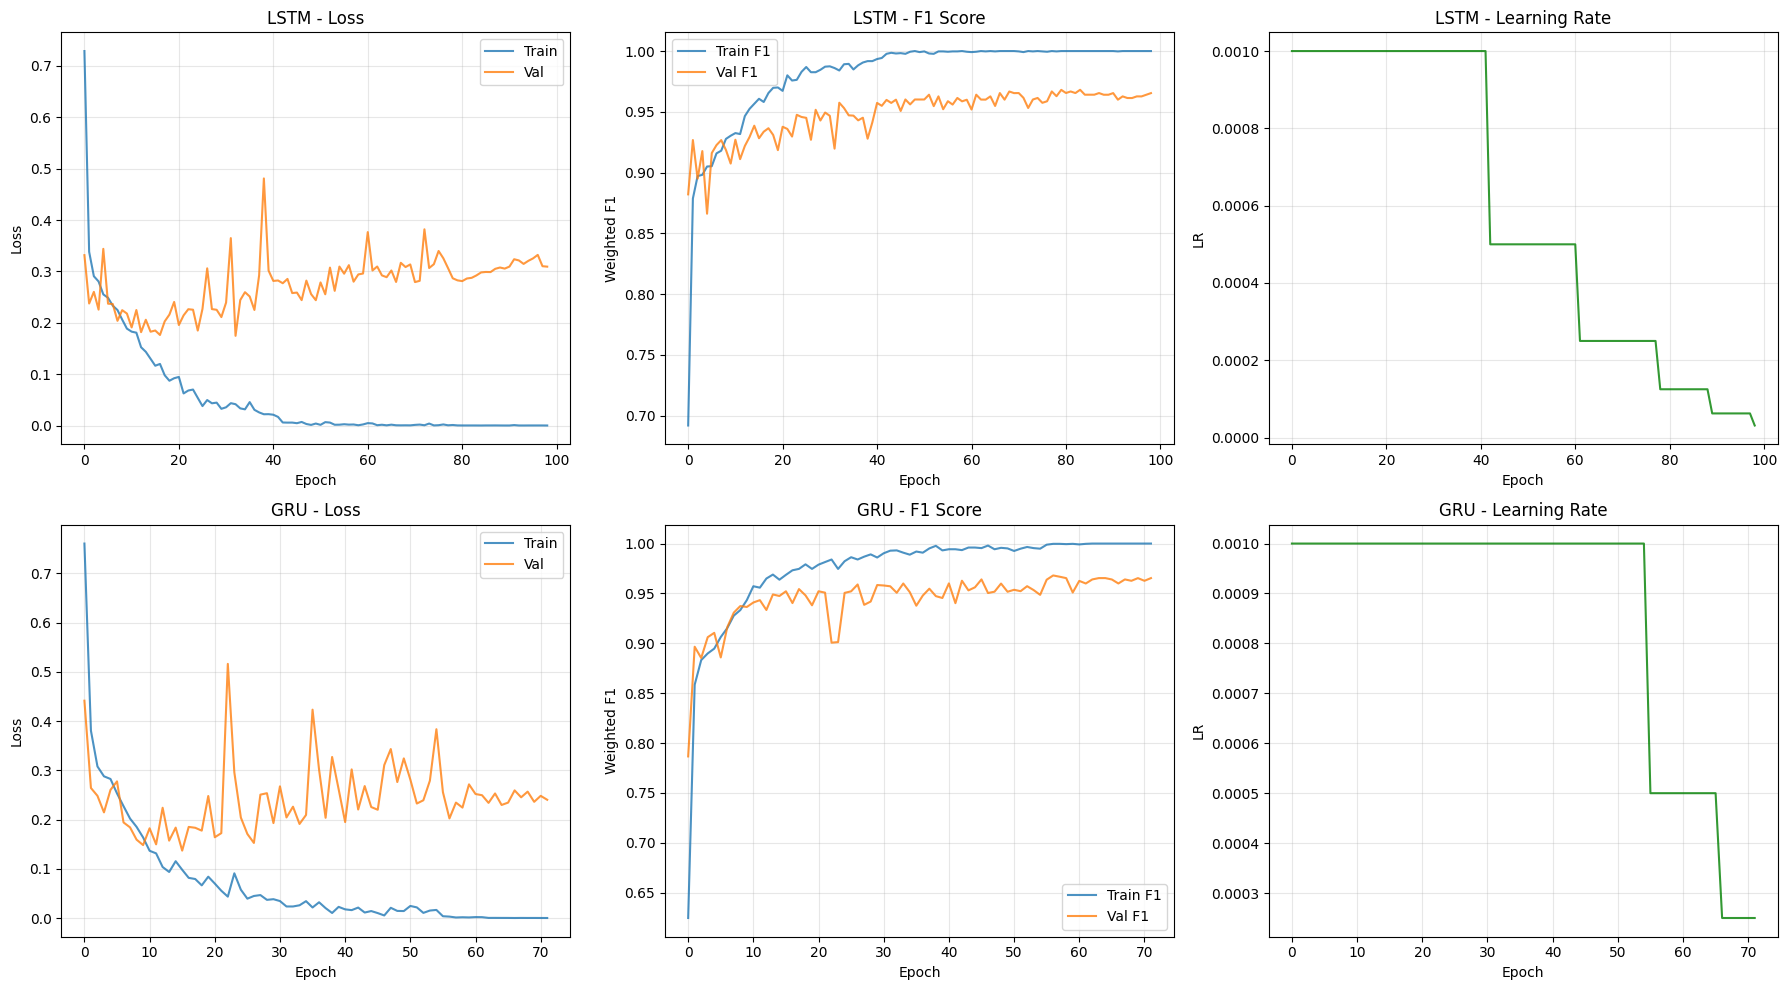

In [29]:
"""
Visualisasi loss curves dan F1 score untuk LSTM dan GRU.
"""

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

"""LSTM plots"""
axes[0, 0].plot(lstm_history['train_loss'], label='Train', alpha=0.8)
axes[0, 0].plot(lstm_history['val_loss'], label='Val', alpha=0.8)
axes[0, 0].set_title('LSTM - Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(lstm_history['train_f1'], label='Train F1', alpha=0.8)
axes[0, 1].plot(lstm_history['val_f1'], label='Val F1', alpha=0.8)
axes[0, 1].set_title('LSTM - F1 Score')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Weighted F1')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(lstm_history['lr'], color='green', alpha=0.8)
axes[0, 2].set_title('LSTM - Learning Rate')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('LR')
axes[0, 2].grid(True, alpha=0.3)

"""GRU plots"""
axes[1, 0].plot(gru_history['train_loss'], label='Train', alpha=0.8)
axes[1, 0].plot(gru_history['val_loss'], label='Val', alpha=0.8)
axes[1, 0].set_title('GRU - Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(gru_history['train_f1'], label='Train F1', alpha=0.8)
axes[1, 1].plot(gru_history['val_f1'], label='Val F1', alpha=0.8)
axes[1, 1].set_title('GRU - F1 Score')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Weighted F1')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(gru_history['lr'], color='green', alpha=0.8)
axes[1, 2].set_title('GRU - Learning Rate')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('LR')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparative Evaluation

In [30]:
"""
Evaluasi ketiga model pada test set.
(Accuracy, Weighted F1, Macro F1, dan per-class metrics)
"""

def get_test_predictions_rnn(model, loader):
    """Prediksi dari RNN model"""
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    return np.array(all_preds), np.array(all_labels)


"""LSTM predictions"""
lstm_preds, test_labels = get_test_predictions_rnn(lstm_model, test_loader)

"""GRU predictions"""
gru_preds, _ = get_test_predictions_rnn(gru_model, test_loader)

"""XGBoost predictions"""
xgb_preds = xgb_model.predict(X_test_tab)

"""Compute metrics untuk setiap model"""
results = {}
for model_name, preds, labels in [
    ('LSTM', lstm_preds, test_labels),
    ('GRU', gru_preds, test_labels),
    ('XGBoost', xgb_preds, y_test_tab)
]:
    results[model_name] = {
        'accuracy': accuracy_score(labels, preds),
        'weighted_f1': f1_score(labels, preds, average='weighted'),
        'macro_f1': f1_score(labels, preds, average='macro'),
        'per_class_precision': precision_score(labels, preds, average=None).tolist(),
        'per_class_recall': recall_score(labels, preds, average=None).tolist(),
        'per_class_f1': f1_score(labels, preds, average=None).tolist()
    }

"""Print comparison table"""
print("\n" + "=" * 60)
print("MODEL COMPARISON - TEST SET")
print("=" * 60)
print(f"{'Model':<12} {'Accuracy':>10} {'W-F1':>10} {'M-F1':>10}")
print("-" * 42)
for model_name, metrics in results.items():
    print(f"{model_name:<12} {metrics['accuracy']:>10.4f} {metrics['weighted_f1']:>10.4f} {metrics['macro_f1']:>10.4f}")

print(f"\nPer-class F1 Scores:")
print(f"{'Model':<12} {'Guided':>10} {'Simplified':>12} {'Standard':>10} {'Efficient':>12}")
print("-" * 56)
for model_name, metrics in results.items():
    f1s = metrics['per_class_f1']
    print(f"{model_name:<12} {f1s[0]:>10.4f} {f1s[1]:>12.4f} {f1s[2]:>10.4f} {f1s[3]:>12.4f}")


MODEL COMPARISON - TEST SET
Model          Accuracy       W-F1       M-F1
------------------------------------------
LSTM             0.9440     0.9444     0.9360
GRU              0.9533     0.9537     0.9469
XGBoost          0.9667     0.9667     0.9627

Per-class F1 Scores:
Model            Guided   Simplified   Standard    Efficient
--------------------------------------------------------
LSTM             0.8692       0.9227     0.9790       0.9732
GRU              0.8963       0.9398     0.9808       0.9705
XGBoost          0.9345       0.9618     0.9809       0.9735


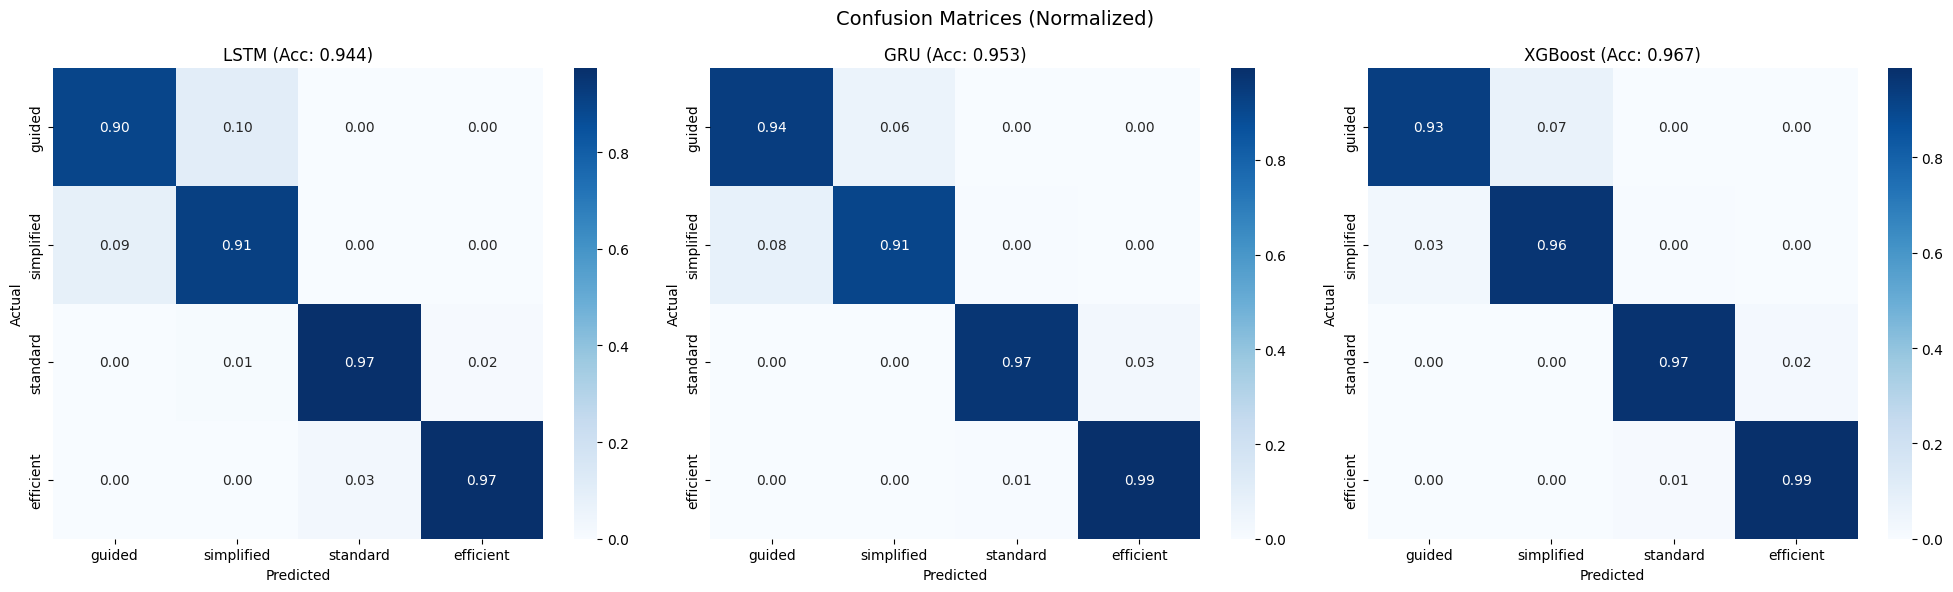

In [31]:
"""
Confusion matrix heatmaps untuk ketiga model.
"""

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (model_name, preds, labels) in enumerate([
    ('LSTM', lstm_preds, test_labels),
    ('GRU', gru_preds, test_labels),
    ('XGBoost', xgb_preds, y_test_tab)
]):
    cm = confusion_matrix(labels, preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=config['class_names'],
        yticklabels=config['class_names'],
        ax=axes[idx]
    )
    axes[idx].set_title(f'{model_name} (Acc: {results[model_name]["accuracy"]:.3f})')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle('Confusion Matrices (Normalized)', fontsize=14)
plt.tight_layout()
plt.show()

## Best Model Selection

In [32]:
best_model_name = max(results, key=lambda k: results[k]['weighted_f1'])
best_metrics = results[best_model_name]

print(f"Best model: {best_model_name}")
print(f"  Weighted F1: {best_metrics['weighted_f1']:.4f}")
print(f"  Accuracy: {best_metrics['accuracy']:.4f}")
print(f"  Macro F1: {best_metrics['macro_f1']:.4f}")

if best_model_name == 'LSTM':
    best_rnn_model = lstm_model
elif best_model_name == 'GRU':
    best_rnn_model = gru_model
else:
    best_rnn_model = None

f"Selected {best_model_name} as the best model with Weighted F1 = {best_metrics['weighted_f1']:.4f}"

Best model: XGBoost
  Weighted F1: 0.9667
  Accuracy: 0.9667
  Macro F1: 0.9627


'Selected XGBoost as the best model with Weighted F1 = 0.9667'

## Feature Importance (XGBoost)

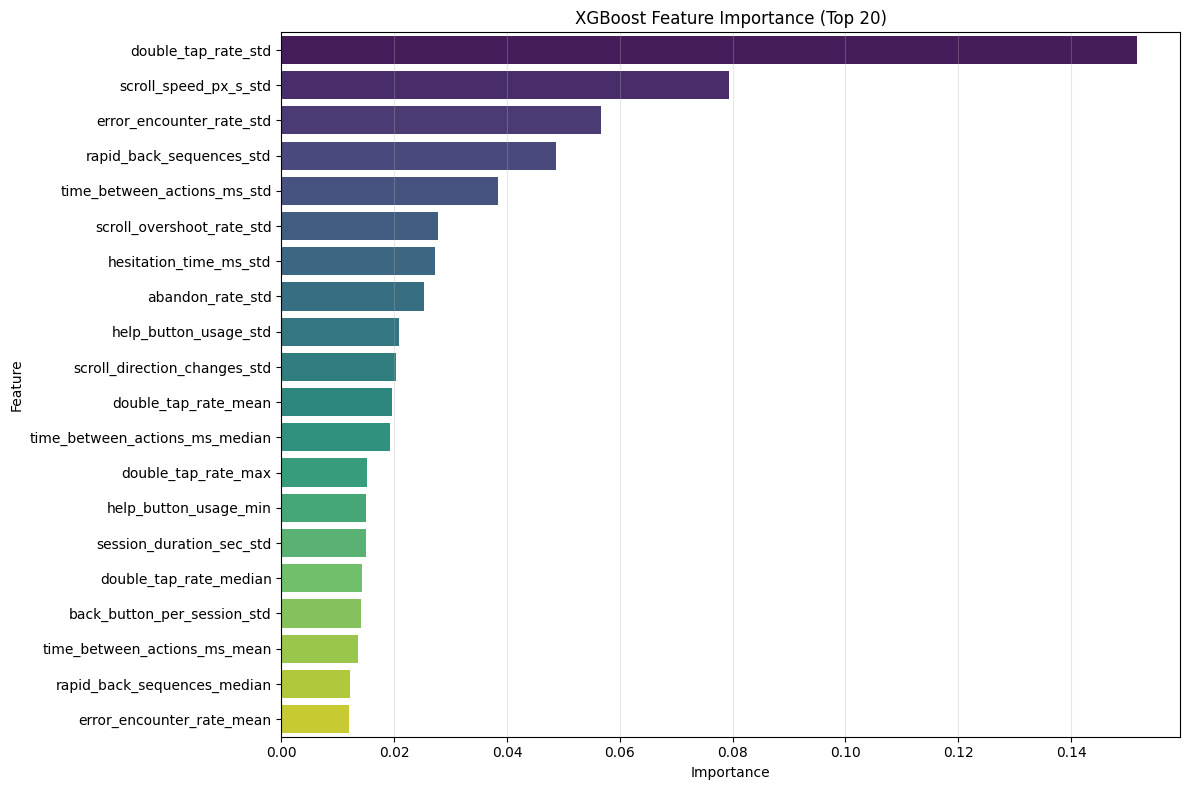

Top 10 most important features:
  double_tap_rate_std                     : 0.1517
  scroll_speed_px_s_std                   : 0.0793
  error_encounter_rate_std                : 0.0567
  rapid_back_sequences_std                : 0.0486
  time_between_actions_ms_std             : 0.0385
  scroll_overshoot_rate_std               : 0.0277
  hesitation_time_ms_std                  : 0.0273
  abandon_rate_std                        : 0.0254
  help_button_usage_std                   : 0.0209
  scroll_direction_changes_std            : 0.0203


In [33]:
importances = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': tab_feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

"""Plot top 20 features"""
top_n = 20
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_features,
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title(f'XGBoost Feature Importance (Top {top_n})')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"Top 10 most important features:")
for _, row in feature_importance_df.head(10).iterrows():
    print(f"  {row['feature']:40s}: {row['importance']:.4f}")

## Per-Class Analysis

In [34]:
"""
t-SNE visualisasi dari embeddings model RNN terbaik.
"""

if best_rnn_model is not None:
    best_rnn_model.eval()
    all_embeddings = []
    all_labels_tsne = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            emb = best_rnn_model.get_embeddings(X_batch)
            all_embeddings.append(emb.cpu().numpy())
            all_labels_tsne.extend(y_batch.numpy())

    embeddings = np.concatenate(all_embeddings, axis=0)
    labels_tsne = np.array(all_labels_tsne)

    tsne = TSNE(n_components=2, random_state=config['random_seed'], perplexity=30)
    embeddings_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
    for cls_idx, cls_name in enumerate(config['class_names']):
        mask = labels_tsne == cls_idx
        plt.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=colors[cls_idx],
            label=cls_name,
            alpha=0.6,
            s=20
        )

    plt.title(f't-SNE Visualization ({best_model_name} Embeddings)')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Best model is XGBoost, skipping t-SNE embedding visualization")

Best model is XGBoost, skipping t-SNE embedding visualization


In [35]:
"""
Classification report detail untuk model terbaik.
"""

if best_model_name == 'XGBoost':
    best_preds = xgb_preds
    best_labels = y_test_tab
elif best_model_name == 'LSTM':
    best_preds = lstm_preds
    best_labels = test_labels
else:
    best_preds = gru_preds
    best_labels = test_labels

print(f"\nDetailed Classification Report ({best_model_name}):")
print("=" * 60)
print(classification_report(
    best_labels,
    best_preds,
    target_names=config['class_names']
))


Detailed Classification Report (XGBoost):
              precision    recall  f1-score   support

      guided       0.94      0.93      0.93       115
  simplified       0.96      0.96      0.96       222
    standard       0.99      0.97      0.98       264
   efficient       0.96      0.99      0.97       149

    accuracy                           0.97       750
   macro avg       0.96      0.96      0.96       750
weighted avg       0.97      0.97      0.97       750



## Model Export

In [36]:
"""
Export LSTM dan GRU model ke PyTorch checkpoint dan ONNX.
"""

models_dir = f'{models_path}'
Path(models_dir).mkdir(parents=True, exist_ok=True)

"""Save LSTM checkpoint"""
torch.save({
    'model_state_dict': lstm_model.state_dict(),
    'config': config,
    'architecture': {
        'type': 'LSTMClassifier',
        'input_size': input_size,
        'hidden_size': config['lstm_hidden_size'],
        'num_layers': config['num_rnn_layers'],
        'num_classes': config['num_classes'],
        'bidirectional': config['bidirectional']
    },
    'test_metrics': results['LSTM']
}, f'{models_dir}/lstm_classifier.pt')
print(f"Saved: lstm_classifier.pt")

"""Save GRU checkpoint"""
torch.save({
    'model_state_dict': gru_model.state_dict(),
    'config': config,
    'architecture': {
        'type': 'GRUClassifier',
        'input_size': input_size,
        'hidden_size': config['gru_hidden_size'],
        'num_layers': config['num_rnn_layers'],
        'num_classes': config['num_classes'],
        'bidirectional': config['bidirectional']
    },
    'test_metrics': results['GRU']
}, f'{models_dir}/gru_classifier.pt')
print(f"Saved: gru_classifier.pt")

"""Sequence length dari config"""
seq_length = config['sessions_per_user']

"""Export LSTM to ONNX"""
lstm_model.eval()
dummy_input = torch.randn(1, seq_length, input_size).to(device)

torch.onnx.export(
    lstm_model,
    dummy_input,
    f'{models_dir}/lstm_classifier.onnx',
    opset_version=13,
    input_names=['input'],
    output_names=['output'],
    dynamo=False,
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)
print(f"Saved: lstm_classifier.onnx")

"""Export GRU to ONNX"""
gru_model.eval()
torch.onnx.export(
    gru_model,
    dummy_input,
    f'{models_dir}/gru_classifier.onnx',
    opset_version=13,
    input_names=['input'],
    output_names=['output'],
    dynamo=False,
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)
print(f"Saved: gru_classifier.onnx")

Saved: lstm_classifier.pt
Saved: gru_classifier.pt
Saved: lstm_classifier.onnx
Saved: gru_classifier.onnx


In [37]:
"""
Export XGBoost model ke JSON format dan deployment parameters.
"""

"""XGBoost native JSON format"""
xgb_model.save_model(f'{models_dir}/xgboost_classifier.json')
print(f"Saved: xgboost_classifier.json")

"""Export deployment params untuk inference pipeline"""
deployment_params = {
    'sequence_length': config['sessions_per_user'],
    'num_features': config['num_session_features'],
    'num_classes': config['num_classes'],
    'class_names': config['class_names'],
    'feature_names': feature_cols,
    'scaler_mean': seq_scaler.mean_.tolist(),
    'scaler_scale': seq_scaler.scale_.tolist(),
    'tab_feature_cols': tab_feature_cols,
    'tab_scaler_mean': tab_scaler.mean_.tolist(),
    'tab_scaler_scale': tab_scaler.scale_.tolist(),
    'best_model': best_model_name,
    'best_model_metrics': best_metrics
}

with open(f'{models_dir}/deployment_params.json', 'w') as f:
    json.dump(deployment_params, f, indent=2)
print(f"Saved: deployment_params.json")

Saved: xgboost_classifier.json
Saved: deployment_params.json


In [38]:
"""
Verifikasi ukuran file model.
"""

model_files = [
    'lstm_classifier.pt',
    'lstm_classifier.onnx',
    'gru_classifier.pt',
    'gru_classifier.onnx',
    'xgboost_classifier.json',
    'deployment_params.json'
]

print("Model file sizes:")
print("=" * 50)
for filename in model_files:
    filepath = f'{models_dir}/{filename}'
    if os.path.exists(filepath):
        size_bytes = os.path.getsize(filepath)
        size_kb = size_bytes / 1024
        size_mb = size_kb / 1024
        status = 'OK' if size_mb < 1.0 else 'WARN: > 1MB'
        print(f"  {filename:30s}: {size_kb:8.1f} KB ({size_mb:.3f} MB) [{status}]")
    else:
        print(f"  {filename:30s}: NOT FOUND")

Model file sizes:
  lstm_classifier.pt            :    658.3 KB (0.643 MB) [OK]
  lstm_classifier.onnx          :    654.3 KB (0.639 MB) [OK]
  gru_classifier.pt             :    521.3 KB (0.509 MB) [OK]
  gru_classifier.onnx           :    516.3 KB (0.504 MB) [OK]
  xgboost_classifier.json       :   3198.8 KB (3.124 MB) [WARN: > 1MB]
  deployment_params.json        :      7.3 KB (0.007 MB) [OK]


## ONNX Verification

In [39]:
import onnx
import onnxruntime as ort

"""Verify LSTM ONNX"""
onnx_model = onnx.load(f'{models_dir}/lstm_classifier.onnx')
onnx.checker.check_model(onnx_model)
print("LSTM ONNX model is valid")

"""Compare ONNX vs PyTorch predictions"""
test_input = X_test_seq[:5].numpy()

"""PyTorch prediction"""
lstm_model.eval()
with torch.no_grad():
    pt_output = lstm_model(X_test_seq[:5].to(device)).cpu().numpy()

"""ONNX prediction"""
ort_session = ort.InferenceSession(f'{models_dir}/lstm_classifier.onnx')
ort_output = ort_session.run(None, {'input': test_input})[0]

"""Compare"""
max_diff = np.abs(pt_output - ort_output).max()
print(f"\nLSTM ONNX vs PyTorch max difference: {max_diff:.8f}")
print(f"Match: {'YES' if max_diff < 1e-4 else 'NO - investigate'}")

"""Verify GRU ONNX"""
onnx_gru = onnx.load(f'{models_dir}/gru_classifier.onnx')
onnx.checker.check_model(onnx_gru)
print(f"\nGRU ONNX model is valid")

gru_model.eval()
with torch.no_grad():
    pt_gru_output = gru_model(X_test_seq[:5].to(device)).cpu().numpy()

ort_gru_session = ort.InferenceSession(f'{models_dir}/gru_classifier.onnx')
ort_gru_output = ort_gru_session.run(None, {'input': test_input})[0]

max_diff_gru = np.abs(pt_gru_output - ort_gru_output).max()
print(f"GRU ONNX vs PyTorch max difference: {max_diff_gru:.8f}")
print(f"Match: {'YES' if max_diff_gru < 1e-4 else 'NO - investigate'}")

LSTM ONNX model is valid

LSTM ONNX vs PyTorch max difference: 0.00001431
Match: YES

GRU ONNX model is valid
GRU ONNX vs PyTorch max difference: 0.00001049
Match: YES


## Summary Report

In [40]:
summary = {
    'task': 'Adaptive Cognitive UI - Data Generation and Model Training',
    'timestamp': datetime.now().isoformat(),
    'data': {
        'num_users': config['num_users'],
        'sessions_per_user': config['sessions_per_user'],
        'total_sessions': config['num_users'] * config['sessions_per_user'],
        'num_features': config['num_session_features'],
        'split_ratio': '70/15/15',
        'train_size': len(train_idx),
        'val_size': len(val_idx),
        'test_size': len(test_idx)
    },
    'models': {
        'LSTM': {
            'parameters': lstm_params,
            'size_kb': lstm_size_kb,
            'epochs_trained': len(lstm_history['train_loss']),
            'test_accuracy': results['LSTM']['accuracy'],
            'test_weighted_f1': results['LSTM']['weighted_f1'],
            'test_macro_f1': results['LSTM']['macro_f1'],
            'per_class_f1': results['LSTM']['per_class_f1']
        },
        'GRU': {
            'parameters': gru_params,
            'size_kb': gru_size_kb,
            'epochs_trained': len(gru_history['train_loss']),
            'test_accuracy': results['GRU']['accuracy'],
            'test_weighted_f1': results['GRU']['weighted_f1'],
            'test_macro_f1': results['GRU']['macro_f1'],
            'per_class_f1': results['GRU']['per_class_f1']
        },
        'XGBoost': {
            'n_estimators': config['xgb_n_estimators'],
            'max_depth': config['xgb_max_depth'],
            'test_accuracy': results['XGBoost']['accuracy'],
            'test_weighted_f1': results['XGBoost']['weighted_f1'],
            'test_macro_f1': results['XGBoost']['macro_f1'],
            'per_class_f1': results['XGBoost']['per_class_f1']
        }
    },
    'best_model': best_model_name,
    'best_model_weighted_f1': best_metrics['weighted_f1'],
    'class_names': config['class_names'],
    'exports': {
        'raw_data': ['ui-behavior-sessions.csv', 'ui-profiles.csv'],
        'models': ['lstm_classifier.pt', 'lstm_classifier.onnx',
                   'gru_classifier.pt', 'gru_classifier.onnx',
                   'xgboost_classifier.json', 'deployment_params.json']
    },
    'deployment_ready': True
}


print('\n' + '=' * 60)
print('ADAPTIVE COGNITIVE UI - COMPLETE')
print('=' * 60)
print(f"\nBest Model: {best_model_name}")
print(f"  Accuracy:    {best_metrics['accuracy']:.4f}")
print(f"  Weighted F1: {best_metrics['weighted_f1']:.4f}")
print(f"  Macro F1:    {best_metrics['macro_f1']:.4f}")
print(f"\nAll models comparison:")
for name, metrics in results.items():
    marker = ' <-- BEST' if name == best_model_name else ''
    print(f"  {name:10s}: Acc={metrics['accuracy']:.4f}, W-F1={metrics['weighted_f1']:.4f}{marker}")
print(f"\nFiles saved to:")
print(f"  Raw data:  {datas_path}/")
print(f"  Models:    {models_dir}/")
print(f"\nReady for on-device deployment via ONNX")


ADAPTIVE COGNITIVE UI - COMPLETE

Best Model: XGBoost
  Accuracy:    0.9667
  Weighted F1: 0.9667
  Macro F1:    0.9627

All models comparison:
  LSTM      : Acc=0.9440, W-F1=0.9444
  GRU       : Acc=0.9533, W-F1=0.9537
  XGBoost   : Acc=0.9667, W-F1=0.9667 <-- BEST

Files saved to:
  Raw data:  /content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon/datas/
  Models:    /content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon/models/

Ready for on-device deployment via ONNX


# Inference Pipeline Guide

Panduan penggunakan model XGBoost dalam production environment.

### File Dependencies untuk Production
- **Model file**: `models/xgboost_classifier.json` (XGBoost native format)
- **Config file**: `models/deployment_params.json` (preprocessing parameters)

### Input Schema
Raw session data per user dalam format DataFrame/JSON dengan 14 behavioral features:
```json
{
  "user_sessions": [
    {
      "hesitation_time_ms": 1200.5,
      "back_button_per_session": 3,
      "rapid_back_sequences": 1,
      "scroll_speed_px_s": 450.2,
      "scroll_direction_changes": 8,
      "scroll_overshoot_rate": 0.15,
      "abandon_rate": 0.05,
      "tap_precision_score": 0.87,
      "double_tap_rate": 0.02,
      "time_between_actions_ms": 2500.0,
      "feature_usage_breadth": 0.6,
      "session_duration_sec": 180.5,
      "error_encounter_rate": 0.03,
      "help_button_usage": 2
    }
  ]
}
```

### Output Schema
```json
{
  "ui_profile": "standard",
  "confidence": 0.87,
  "label": 2,
  "all_probabilities": {
    "guided": 0.05,
    "simplified": 0.15,
    "standard": 0.87,
    "efficient": 0.23
  }
}
```

## XGBoost Inference

Model ini memprediksi UI profile berdasarkan data behavioral user dari 20 session dengan 14 features per session.

In [41]:
"""Load model artifacts untuk inference"""

import json
import numpy as np
import pandas as pd
import xgboost as xgb

# Load deployment parameters
deploy_params_path = f"{models_path}/deployment_params.json"
with open(deploy_params_path, 'r') as f:
    params = json.load(f)

# Extract parameters untuk XGBoost inference
tab_feature_cols = params['tab_feature_cols']  
tab_scaler_mean = np.array(params['tab_scaler_mean']) 
tab_scaler_scale = np.array(params['tab_scaler_scale'])  
class_names = params['class_names']  # ["guided", "simplified", "standard", "efficient"]

print(f"Loaded {len(tab_feature_cols)} tabular features")
print(f"Class names: {class_names}")

# Load XGBoost model
xgb_model_path = f"{models_path}/xgboost_classifier.json"
inference_model = xgb.XGBClassifier()
inference_model.load_model(xgb_model_path)

print(f"XGBoost model loaded from: {xgb_model_path}")
print(f"Model classes: {inference_model.classes_}")
print(f"Number of features expected: {inference_model.n_features_in_}")

Loaded 71 tabular features
Class names: ['guided', 'simplified', 'standard', 'efficient']
XGBoost model loaded from: /content/drive/MyDrive/Kuliah/Lomba/Asean Singapore Hackathon/models/xgboost_classifier.json
Model classes: [0 1 2 3]
Number of features expected: 71


In [42]:
def preprocess_user_sessions(sessions_df):
    """
    Preprocessing pipeline untuk single user sessions data
    
    Args:
        sessions_df (DataFrame): Raw session data untuk 1 user dengan columns:
            ['hesitation_time_ms', 'back_button_per_session', 'rapid_back_sequences',
             'scroll_speed_px_s', 'scroll_direction_changes', 'scroll_overshoot_rate', 
             'abandon_rate', 'tap_precision_score', 'double_tap_rate', 
             'time_between_actions_ms', 'feature_usage_breadth', 'session_duration_sec', 
             'error_encounter_rate', 'help_button_usage']
    
    Returns:
        numpy.ndarray: Scaled features siap untuk model prediction (71 features)
    """
    
    behavioral_features = [
        'hesitation_time_ms', 'back_button_per_session', 'rapid_back_sequences',
        'scroll_speed_px_s', 'scroll_direction_changes', 'scroll_overshoot_rate',
        'abandon_rate', 'tap_precision_score', 'double_tap_rate', 'time_between_actions_ms',
        'feature_usage_breadth', 'session_duration_sec', 'error_encounter_rate', 'help_button_usage'
    ]
    
    missing_cols = [col for col in behavioral_features if col not in sessions_df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    behavioral_data = sessions_df[behavioral_features]
    
    agg_stats = []
    agg_funcs = ['mean', 'median', 'std', 'min', 'max']
    
    for feature in behavioral_features:
        for stat in agg_funcs:
            if stat == 'std':
                value = behavioral_data[feature].std()
                if pd.isna(value):
                    value = 0.0
            else:
                value = getattr(behavioral_data[feature], stat)()
            agg_stats.append(value)
    
    sessions_count = len(sessions_df)
    agg_stats.append(sessions_count)
    
    X = np.array(agg_stats).reshape(1, -1)
    
    X_scaled = (X - tab_scaler_mean) / tab_scaler_scale
    
    return X_scaled

print("Preprocessing function defined")
print(f"Expected output shape: (1, {len(tab_feature_cols)})")
print(f"Feature aggregation: 14 behavioral features x 5 stats + 1 count = {14*5+1} features")

Preprocessing function defined
Expected output shape: (1, 71)
Feature aggregation: 14 behavioral features x 5 stats + 1 count = 71 features


In [43]:
def predict_ui_profile(sessions_df):
    """
    Full inference pipeline: preprocessing + prediction
    
    Args:
        sessions_df (DataFrame): Raw session data untuk 1 user 
        
    Returns:
        dict: {
            'ui_profile': str,           # nama class (guided/simplified/standard/efficient)
            'confidence': float,         # probabilitas tertinggi (0-1)
            'label': int,               # integer label (0-3)
            'all_probabilities': dict   # probabilitas semua class
        }
    """
    
    try:
        X_scaled = preprocess_user_sessions(sessions_df)
        
        predicted_label = inference_model.predict(X_scaled)[0] 
        probabilities = inference_model.predict_proba(X_scaled)[0]  
        
        predicted_class = class_names[predicted_label]
        confidence = float(probabilities[predicted_label])
        
        all_probs = {class_names[i]: float(probabilities[i]) for i in range(len(class_names))}
        
        return {
            'ui_profile': predicted_class,
            'confidence': confidence,
            'label': int(predicted_label),
            'all_probabilities': all_probs
        }
        
    except Exception as e:
        return {
            'error': str(e),
            'ui_profile': None,
            'confidence': 0.0,
            'label': -1,
            'all_probabilities': {}
        }

print("Inference function defined")
print("Input: DataFrame dengan session data untuk 1 user")
print("Output: Dictionary dengan predicted UI profile + confidence scores")

Inference function defined
Input: DataFrame dengan session data untuk 1 user
Output: Dictionary dengan predicted UI profile + confidence scores


In [44]:
"""Demo: Single User Inference"""

sample_user_id = 1
sample_sessions = sessions_df[sessions_df['user_id'] == sample_user_id].copy()

print(f"=== DEMO: Single User Inference ===")
print(f"User ID: {sample_user_id}")
print(f"Number of sessions: {len(sample_sessions)}")

ground_truth = users[users['user_id'] == sample_user_id]['ui_profile'].iloc[0]
ground_truth_label = users[users['user_id'] == sample_user_id]['ui_profile_label'].iloc[0]

print(f"Ground Truth: {ground_truth} (label: {ground_truth_label})")
print()

result = predict_ui_profile(sample_sessions)

if 'error' not in result:
    print("PREDICTION RESULT:")
    print(f"   Predicted Profile: {result['ui_profile']}")
    print(f"   Label: {result['label']}")
    print(f"   Confidence: {result['confidence']:.3f}")
    print()
    
    print("ALL CLASS PROBABILITIES:")
    for class_name, prob in result['all_probabilities'].items():
        marker = ">>" if class_name == result['ui_profile'] else "  "
        print(f"   {marker} {class_name:>10}: {prob:.3f}")
    print()
    
    is_correct = result['ui_profile'] == ground_truth
    status = "CORRECT" if is_correct else "INCORRECT"
    print(f"Prediction vs Ground Truth: {status}")
    
else:
    print(f"ERROR: {result['error']}")

print(f"\n--- Sample session data (first 3 rows) ---")
display_cols = ['hesitation_time_ms', 'scroll_speed_px_s', 'tap_precision_score', 'session_duration_sec']
print(sample_sessions[display_cols].head(3))

=== DEMO: Single User Inference ===
User ID: 1
Number of sessions: 20
Ground Truth: guided (label: 0)

PREDICTION RESULT:
   Predicted Profile: guided
   Label: 0
   Confidence: 0.997

ALL CLASS PROBABILITIES:
   >>     guided: 0.997
      simplified: 0.003
        standard: 0.000
       efficient: 0.000

Prediction vs Ground Truth: CORRECT

--- Sample session data (first 3 rows) ---
   hesitation_time_ms  scroll_speed_px_s  tap_precision_score  \
0         5391.621822         539.658072             0.679773   
1         3069.064162           0.000000             0.788454   
2        10970.008745         627.527291             0.743192   

   session_duration_sec  
0            542.753007  
1             38.346914  
2            158.783242  


# Model Distribution
## Hugging Face Upload

In [45]:
!pip install huggingface_hub

In [46]:
"""Login ke Hugging Face Hub dari notebook Colab."""
from huggingface_hub import notebook_login, HfApi

notebook_login()

In [47]:
"""Upload model artifacts dari models_path ke Hugging Face Hub."""
from pathlib import Path

HF_REPO_ID = "AzrilFahmiardi/ai-daptive-cognitive-ui"
HF_REPO_PRIVATE = False
HF_COMMIT_MESSAGE = "Upload adaptive cognitive UI artifacts"

files_to_upload = ["xgboost_classifier.json", "deployment_params.json"]
models_directory = Path(models_path)

missing_files = [
    file_name for file_name in files_to_upload
    if not (models_directory / file_name).is_file()
]

if missing_files:
    print("Upload dibatalkan. File berikut tidak ditemukan:")
    for file_name in missing_files:
        print(f"- {models_directory / file_name}")
else:
    api = HfApi()
    api.create_repo(repo_id=HF_REPO_ID, private=HF_REPO_PRIVATE, exist_ok=True)

    uploaded_files = []
    for file_name in files_to_upload:
        local_path = models_directory / file_name
        api.upload_file(
            path_or_fileobj=str(local_path),
            path_in_repo=file_name,
            repo_id=HF_REPO_ID,
            commit_message=HF_COMMIT_MESSAGE
        )
        uploaded_files.append(file_name)

    print("Upload selesai dengan sukses.")
    print(f"Repository: {HF_REPO_ID}")
    print(f"Private: {HF_REPO_PRIVATE}")
    print(f"Commit message: {HF_COMMIT_MESSAGE}")
    print(f"Total file uploaded: {len(uploaded_files)}")
    for file_name in uploaded_files:
        print(f"- {file_name}")

Upload selesai dengan sukses.
Repository: AzrilFahmiardi/ai-daptive-cognitive-ui
Private: False
Commit message: Upload adaptive cognitive UI artifacts
Total file uploaded: 2
- xgboost_classifier.json
- deployment_params.json
